In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os
import time
from scipy.optimize import minimize

current_dir = os.getcwd()
package_dir = current_dir + '/packages'
sys.path.append(package_dir)

import rydberg as rd

In [11]:
q2_T = []
for T in range(11):
    history = np.load(f'data/N10_K1_dt0d1/history_N10_K1_T{T}_dt0d1.npy')
    q2_step = []
    for step in range(history.shape[0]):
        q2_network = []
        for network in range(history.shape[1]):
            pairs_thermalSample = []
            for thermalSample in range(history.shape[2]):
                pairs_thermalSample.append(np.outer(history[-1,network,thermalSample,:,2],history[-1,network,thermalSample,:,2]).flatten())
            pairs_thermalSample = np.array(pairs_thermalSample)
            q2_network.append(np.mean(np.mean(pairs_thermalSample, axis=0)**2))
        q2_network = np.array(q2_network)
        q2_step.append(np.mean(q2_network))
    q2_step = np.array(q2_step)
    q2_T.append(np.mean(q2_step))
    print(T)
q2_T = np.array(q2_T)

0
1
2
3
4
5
6
7
8
9
10


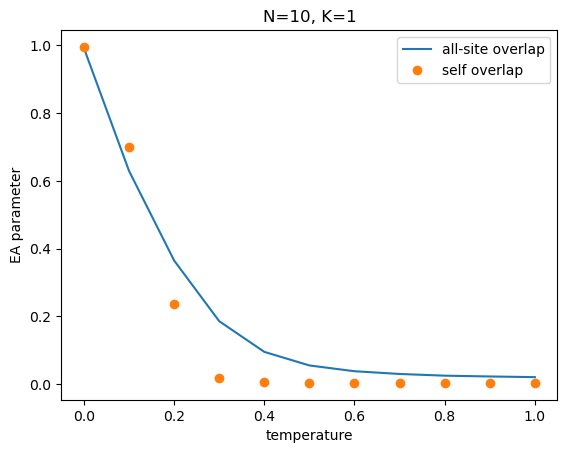

In [18]:
EA = np.load('data/N10_K1_dt0d1/EA_N10_K1_dt0d1.npy')
plt.plot(T_vals, q2_T, label='all-site overlap')
plt.plot(T_vals, EA[:,2], 'o', label='self overlap ')
plt.title('N=10, K=1')
plt.ylabel('EA parameter')
plt.xlabel('temperature')
plt.legend()
plt.savefig('EA.png')

In [9]:
T_vals = np.load('data/N10_K1_dt0d1/T_vals.npy')